In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data_new = pd.read_parquet("data_new.parquet")

In [4]:
data_new.head()

,Año,Juegos,Deporte,Categoria,Atleta,ID_Atleta,NOC,Equipo,Posicion,Empatado,Medalla
0,1912,Verano,Tennis,"Singles, Men (Olympic)",Jean-Francois Blanchy,1,FRA,No_Equipo,17,True,Ninguna
1,1912,Verano,Tennis,"Doubles, Men (Olympic)",Jean-Francois Blanchy,1,FRA,Jean Montariol,<NA>,False,Ninguna
2,1920,Verano,Tennis,"Singles, Men (Olympic)",Jean-Francois Blanchy,1,FRA,No_Equipo,32,True,Ninguna
3,1920,Verano,Tennis,"Doubles, Mixed (Olympic)",Jean-Francois Blanchy,1,FRA,Jeanne Vaussard,8,True,Ninguna
4,1920,Verano,Tennis,"Doubles, Men (Olympic)",Jean-Francois Blanchy,1,FRA,Jacques Brugnon,4,False,Ninguna


Muestra Dato

In [5]:
data_new.shape

(308408, 11)

In [6]:
data_new.info()

<class 'pandas.DataFrame'>
RangeIndex: 308408 entries, 0 to 308407
Data columns (total 11 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Año        305807 non-null  Int64 
 1   Juegos     308408 non-null  string
 2   Deporte    308408 non-null  str   
 3   Categoria  308408 non-null  str   
 4   Atleta     308408 non-null  str   
 5   ID_Atleta  308408 non-null  int64 
 6   NOC        308408 non-null  string
 7   Equipo     308408 non-null  str   
 8   Posicion   283193 non-null  Int64 
 9   Empatado   308408 non-null  bool  
 10  Medalla    308408 non-null  string
dtypes: Int64(2), bool(1), int64(1), str(4), string(3)
memory usage: 49.9 MB


In [7]:
data_new.isna().sum()

Año           2601
Juegos           0
Deporte          0
Categoria        0
Atleta           0
ID_Atleta        0
NOC              0
Equipo           0
Posicion     25215
Empatado         0
Medalla          0
dtype: int64

en cuanto a variables año y posicion se mostraron dato nulo reales, por lo tanto se dejaron haci para evitar borrar dato o sustituir

Revision Datos

In [8]:
data_new.value_counts("NOC")

NOC
USA       21353
FRA       14276
GBR       13170
ITA       12129
CAN       11455
          ...  
TUV           9
YMD           5
SSD           5
NBO           3
No_NOC        1
Name: count, Length: 231, dtype: int64

In [9]:
data_new.value_counts("Juegos")

Juegos
Verano      241298
Invierno     64509
Unknown       2601
Name: count, dtype: int64

se registraron mayor numero de participante con respecto a los juegos de verano superando los 200,000 participaciones, en cuanto a invierno logro mas de 50,000 participaciones, en la seccion de unknown mencionado ante son dato nulo reales

In [10]:
data_new.value_counts("Medalla")

Medalla
Ninguna    264269
Bronze      14810
Gold        14783
Silver      14546
Name: count, dtype: int64

en cuanto a medallas se registra mayor participacion sin ganar una medalla superando los 250.000 participaciones, en cuanto a ganados con un total de 44.139 medalla dada

Resumen

¿Qué países ganan más medallas?

In [11]:
medalla = data_new[data_new["Medalla"] != " "].copy()

In [12]:
paises = (  
    medalla.groupby("NOC")  
    .size() 
    .sort_values(ascending=False)    
    .reset_index(name="medalla")    
)   
paises.head()

,NOC,medalla
0,USA,21353
1,FRA,14276
2,GBR,13170
3,ITA,12129
4,CAN,11455


¿Qué deportes reparten más medallas?

In [13]:
Deporte = (  
    medalla.groupby("Deporte")  
    .size() 
    .sort_values(ascending=False)    
    .reset_index(name="medalla")    
)   
Deporte.head()

,Deporte,medalla
0,Athletics,45916
1,Artistic Gymnastics (Gymnastics),27721
2,Swimming (Aquatics),26526
3,Fencing,12156
4,Shooting,12029


¿Cómo evolucionan las medallas a lo largo del tiempo?

In [14]:
Año = (  
    medalla.groupby("Año")  
    .size() 
    .sort_index()   
    .reset_index(name="medalla")    
)   
Año.head()

,Año,medalla
0,1896,562
1,1900,2395
2,1904,1895
3,1908,3690
4,1912,4883


¿Hay diferencias entre Verano e Invierno?

In [15]:
medal_jueg = (  
    medalla.groupby("Juegos")  
    .size() 
    .sort_values(ascending=False)    
    .reset_index(name="medalla")    
)   
medal_jueg.head()

,Juegos,medalla
0,Verano,241298
1,Invierno,64509
2,Unknown,2601


¿Qué atletas aparecen más veces en el medallero?

In [16]:
atleta = (  
    medalla.groupby("Atleta")  
    .size() 
    .sort_values(ascending=False)    
    .reset_index(name="medalla")    
)   
atleta.head()

,Atleta,medalla
0,Heikki Savolainen,39
1,Josy Stoffel,38
2,Ioannis Theofilakis,37
3,Eric Lemming,34
4,Takashi Ono,33


Cuánto peso tienen los empates?

In [17]:
empate = (  
    data_new.groupby("Empatado")  
    .size() 
    .sort_values(ascending=False)    
    .reset_index(name="Registro")    
)   
empate.head()

,Empatado,Registro
0,False,262468
1,True,45940


los empates en qué deportes aparecen más?

In [18]:
empates = data_new[
    data_new["Empatado"].astype(str).str.lower().isin(["true", "1", "yes", "si", "sí"])
]

In [19]:
empate_deporte = (  
    empates.groupby("Deporte")    
    .size() 
    .sort_values(ascending=False)    
    .reset_index(name="Empates")    
)   
empate_deporte.head()

,Deporte,Empates
0,Artistic Gymnastics (Gymnastics),10438
1,Boxing,5567
2,Judo,3480
3,Shooting,2844
4,Tennis,2811


Graficos

In [20]:
top_paises = (  
        medalla.groupby("NOC")  
        .size() 
        .sort_values(ascending=False)   
        .head(10)   
        .reset_index(name="Medalla")
)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_3868\2994796260.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_paises, x="Medalla", y="NOC", palette="Blues_r")


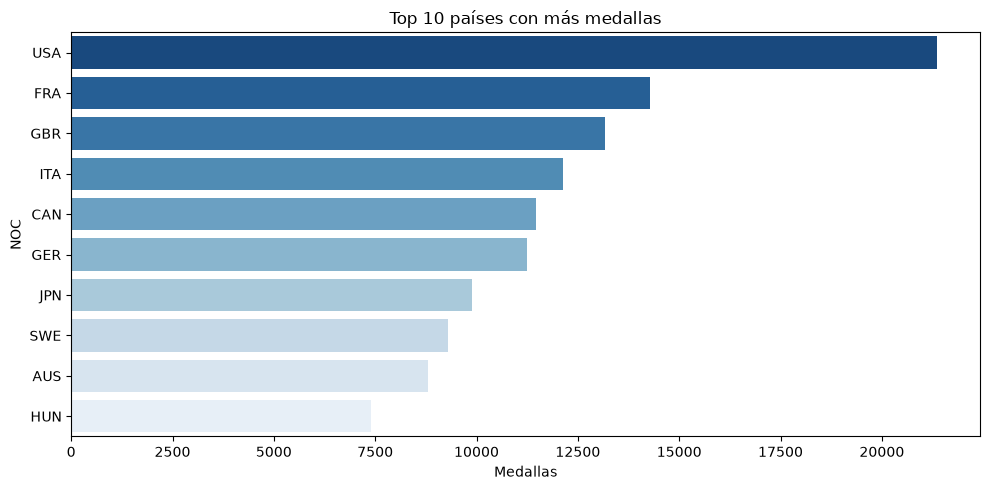

In [21]:
plt.figure(figsize=(10, 5))
sns.barplot(data=top_paises, x="Medalla", y="NOC", palette="Blues_r")
plt.title("Top 10 países con más medallas")
plt.xlabel("Medallas")
plt.ylabel("NOC")
plt.tight_layout()
plt.show()

-“Estados Unidos lidera el medallero con una ventaja notable frente al resto de países.”

-“Francia, Reino Unido e Italia forman el segundo grupo con valores altos pero bastante menores.”

-“La distribución muestra una concentración clara de medallas en pocos países.”

In [22]:
top_deportes = (    
        medalla.groupby("Deporte")  
        .size() 
        .sort_values(ascending=False)   
        .head() 
        .reset_index(name="Medalla")    
)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_3868\486479481.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_deportes, x="Medalla", y="Deporte", palette="Greens_r")


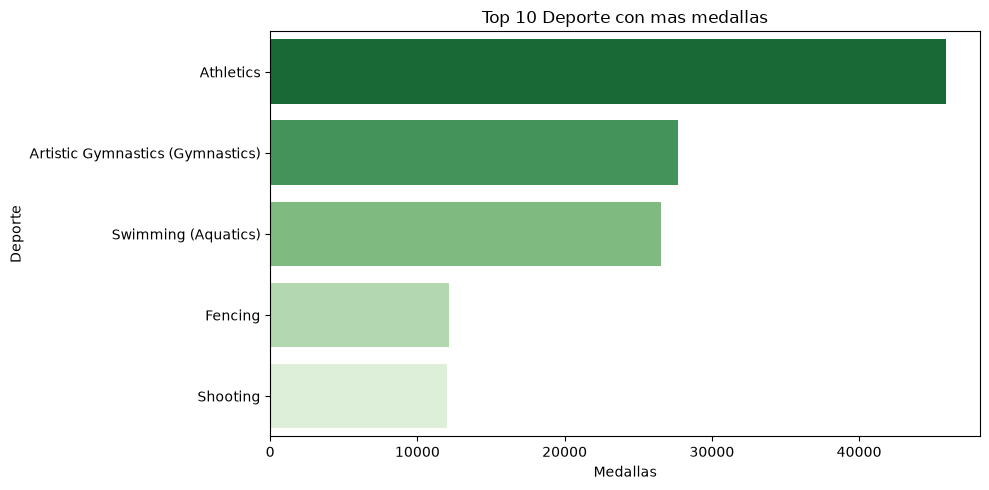

In [23]:
plt.figure(figsize=(10, 5))
sns.barplot(data=top_deportes, x="Medalla", y="Deporte", palette="Greens_r")
plt.title("Top 10 Deporte con mas medallas")
plt.xlabel("Medallas")
plt.ylabel("Deporte")
plt.tight_layout()
plt.show()

Los deportes con mayor número de medallas son Athletics, Artistic Gymnastics y Swimming, lo que indica una alta concentración del medallero en disciplinas muy presentes en los Juegos .

In [24]:
medalla_año = ( 
    medalla.groupby("Año")  
    .size() 
    .sort_index()   
    .reset_index(name="Medalla")    
)

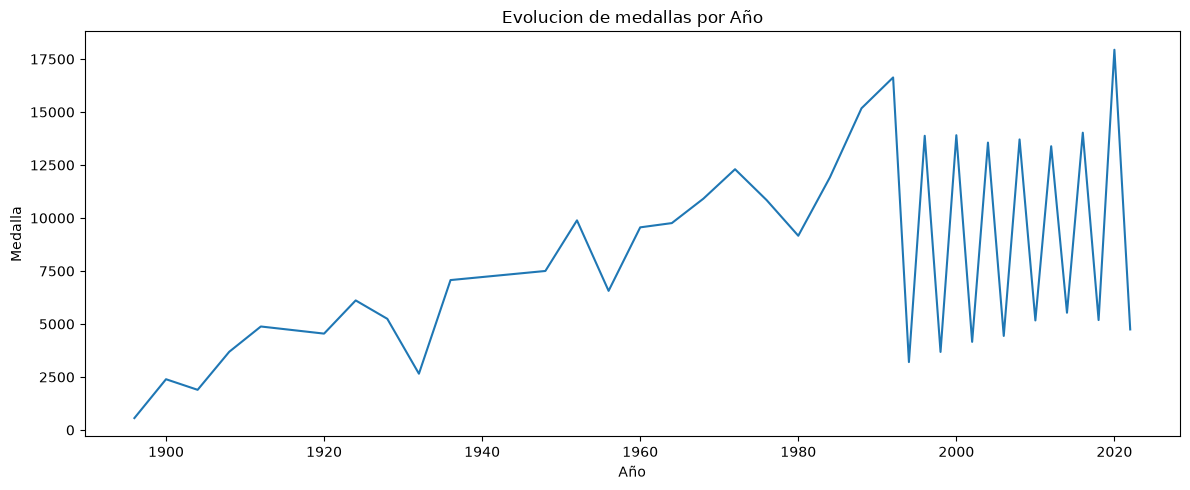

In [25]:
plt.figure(figsize=(12, 5))    
sns.lineplot(data=medalla_año, x="Año", y= "Medalla", markers="o")  
plt.title("Evolucion de medallas por Año")  
plt.xlabel("Año")   
plt.ylabel("Medalla")   
plt.tight_layout()  
plt.show()

La evolución temporal muestra un crecimiento general de las medallas a lo largo del tiempo

In [26]:
medalla_año_tipo = (    
    medalla.groupby(["Año","Juegos"])   
    .size() 
    .reset_index(name="Medalla")    
)

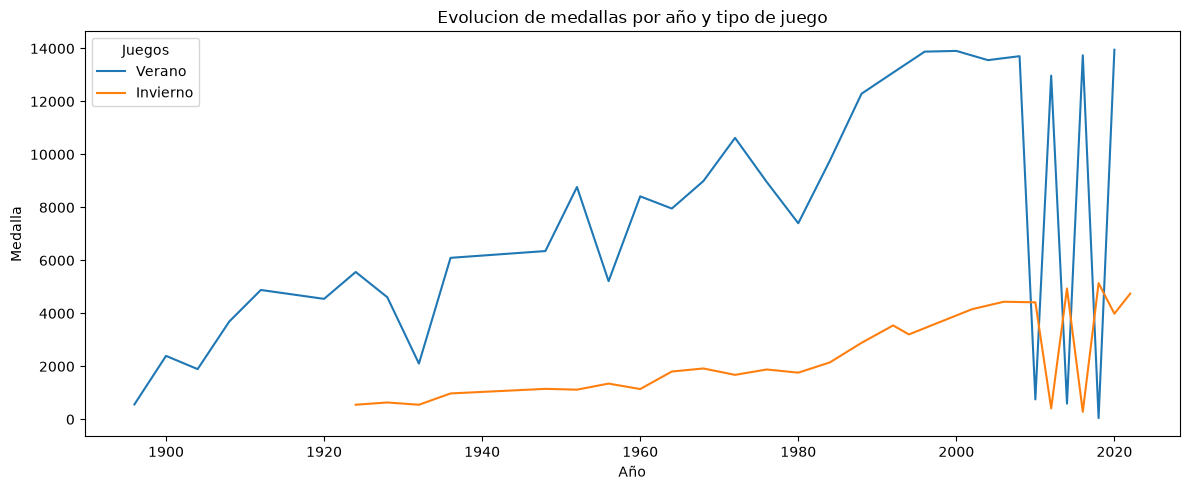

In [27]:
plt.figure(figsize=(12,5))
sns.lineplot(data=medalla_año_tipo, x="Año", y="Medalla", hue="Juegos", markers="0")
plt.title("Evolucion de medallas por año y tipo de juego")
plt.xlabel("Año")   
plt.ylabel("Medalla")
plt.tight_layout()
plt.show()

La evolución temporal muestra una tendencia ascendente del número de medallas, especialmente en la edición de Verano, mientras que Invierno mantiene valores menores pero también crecientes ..

In [28]:
top_atleta = (  
    medalla.groupby("Atleta")   
    .size() 
    .sort_values(ascending=False)   
    .head(10)   
    .reset_index(name="Medalla")    
)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_3868\2035283535.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_atleta, x="Medalla", y="Atleta", palette="magma_r")


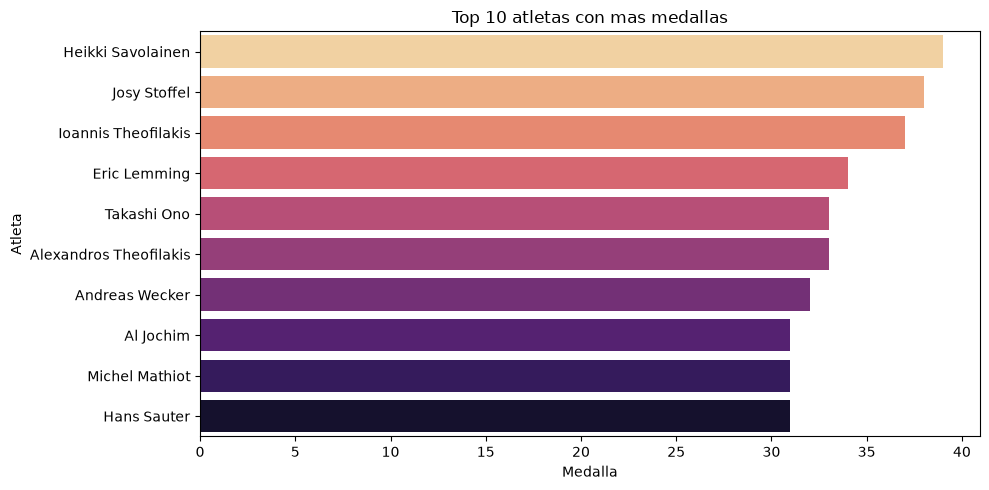

In [29]:
plt.figure(figsize=(10,5))   
sns.barplot(data=top_atleta, x="Medalla", y="Atleta", palette="magma_r")    
plt.title("Top 10 atletas con mas medallas")    
plt.xlabel("Medalla")   
plt.ylabel("Atleta")    
plt.tight_layout() 
plt.show()

El medallero está liderado por un grupo reducido de atletas con muchas apariciones, lo que refleja dominio sostenido en ciertas disciplinas .

In [30]:
empates_deporte = ( 
    data_new[data_new["Empatado"] == True]  
    .groupby("Deporte") 
    .size() 
    .sort_values(ascending=False)   
    .head(10)   
    .reset_index(name="Empate") 
)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_3868\2018024477.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=empates_deporte, x="Empate", y="Deporte", palette="Oranges_r")


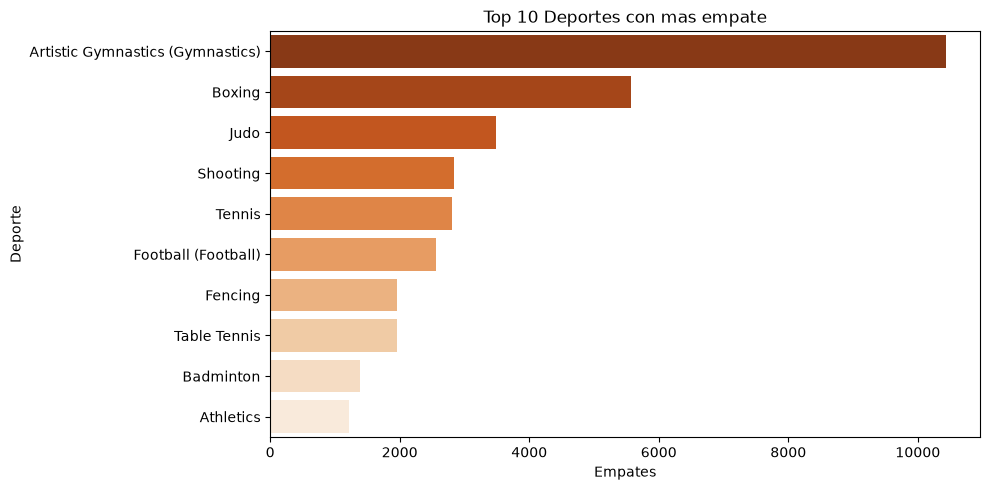

In [31]:
plt.figure(figsize=(10, 5)) 
sns.barplot(data=empates_deporte, x="Empate", y="Deporte", palette="Oranges_r") 
plt.title("Top 10 Deportes con mas empate") 
plt.xlabel("Empates")   
plt.ylabel("Deporte")   
plt.tight_layout()  
plt.show()

Artistic Gymnastics también destaca en empates, junto con Boxing y Judo, lo que sugiere que en esos deportes es más frecuente que varios atletas compartan la misma posición .

Medallas por Tipo

In [32]:
medallas_tipo = (
    data_new[data_new["Medalla"] != "Ninguna"]
    .groupby("Medalla")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="Cantidad")
)

medallas_tipo

,Medalla,Cantidad
0,Bronze,14810
1,Gold,14783
2,Silver,14546


C:\Users\Usuario\AppData\Local\Temp\ipykernel_3868\1857719185.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= medallas_tipo, x="Medalla", y="Cantidad",palette="Set2")


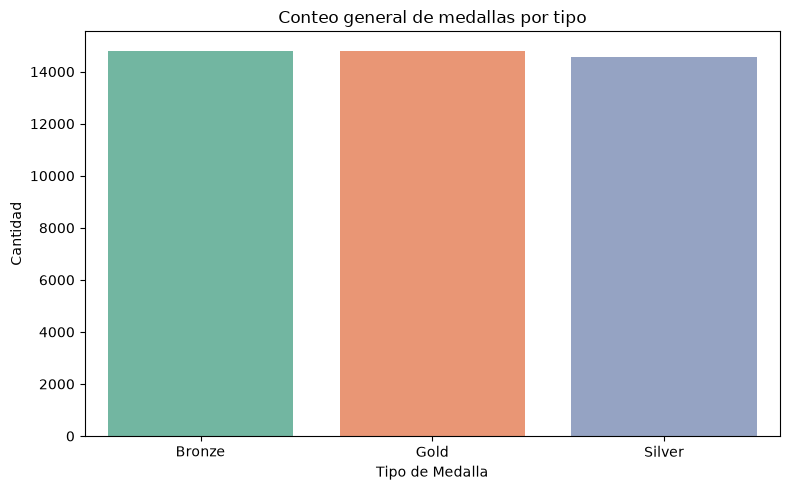

In [33]:
plt.figure(figsize=(8, 5))
sns.barplot(data= medallas_tipo, x="Medalla", y="Cantidad",palette="Set2")
plt.title("Conteo general de medallas por tipo")    
plt.xlabel("Tipo de Medalla")   
plt.ylabel("Cantidad")  
plt.tight_layout()
plt.show()

Este gráfico muestra la distribución general de medallas por tipo. Sirve para contextualizar el volumen total del medallero antes de analizar países, deportes o atletas

Distribución de posiciones

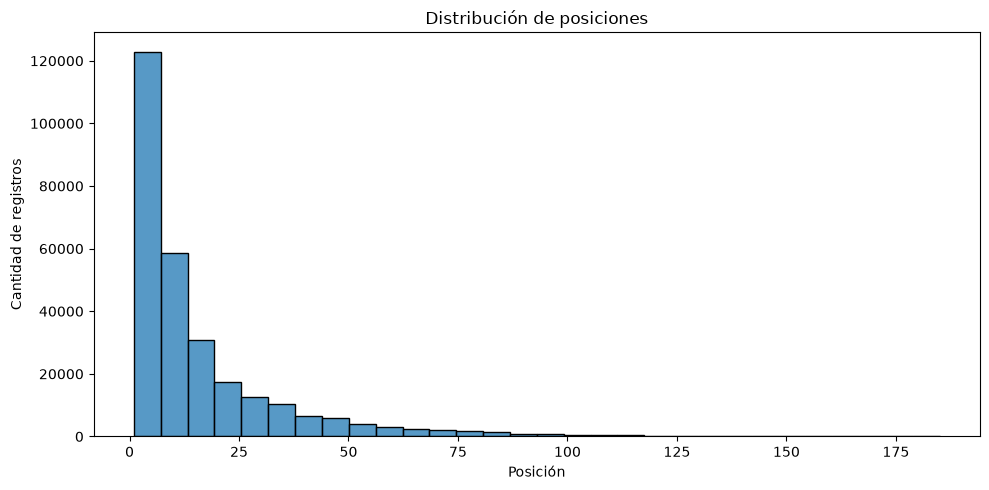

In [34]:
plt.figure(figsize=(10, 5))
sns.histplot(data=data_new, x="Posicion", bins=30)
plt.title("Distribución de posiciones")
plt.xlabel("Posición")
plt.ylabel("Cantidad de registros")
plt.tight_layout()
plt.show()

muestra que la mayoría de registros se concentra en posiciones bajas, lo que da una idea de la dificultad general para llegar al podio

Medallas por NOC y año

In [35]:
medalla_noc_año = (
    data_new[data_new["Medalla"] != "Ninguna"]
    .pivot_table(
        index="NOC",
        columns="Año",
        values="Medalla",
        aggfunc="count",
        fill_value=0
    )
)
medalla_noc_año.head()

Año,1896,1900,1904,1908,1912,1920,1924,1928,1932,1936,...,2004,2006,2008,2010,2012,2014,2016,2018,2020,2022
NOC,,,,,,,,,,,,,,,,,,,,,
AFG,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
AHO,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ALG,0,0,0,0,0,0,0,0,0,0,...,0,0,2,0,1,0,2,0,0,0
AND,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
ANZ,0,0,0,19,10,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [36]:
top10_noc = (
    data_new[data_new["Medalla"] != "Ninguna"]
    .groupby("NOC")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .index
)
heatmap_noc = medalla_noc_año.loc[top10_noc]

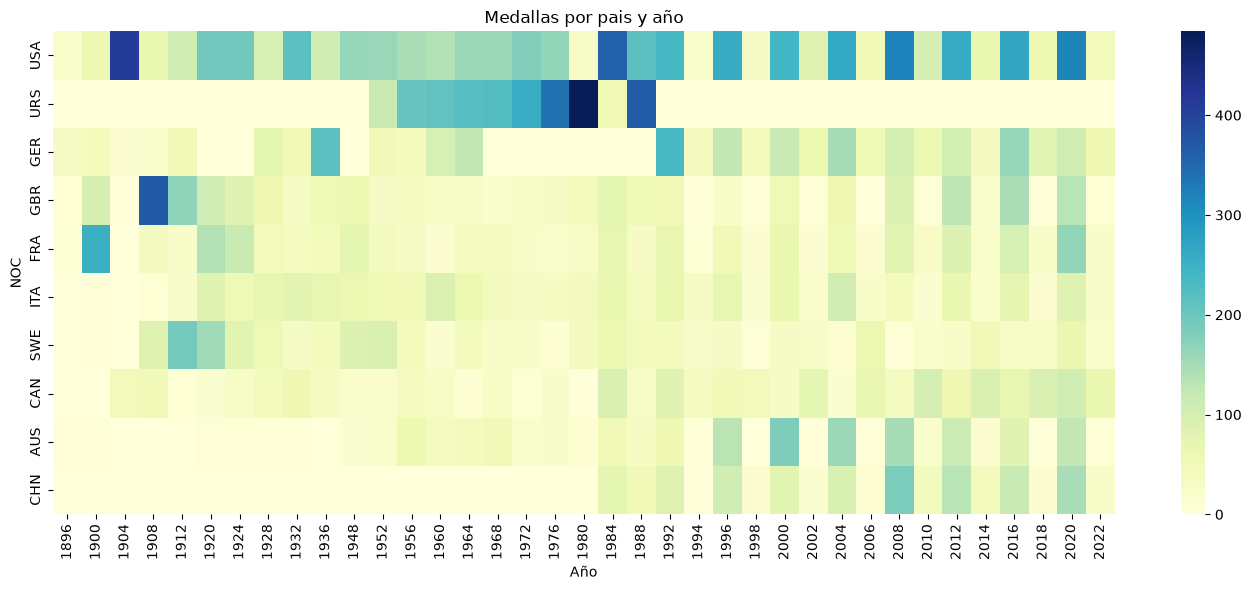

In [38]:
plt.figure(figsize=(14,6))
sns.heatmap(heatmap_noc, cmap="YlGnBu")
plt.title("Medallas por pais y año")
plt.xlabel("Año")
plt.ylabel("NOC")
plt.tight_layout()
plt.show()

USA tiene presencia muy fuerte a lo largo de muchas ediciones.

URS concentra mucho peso en un bloque histórico concreto.

GER, GBR, FRA, SWE, AUS y CHN muestran picos en distintos momentos, lo que ayuda a ver cambios de dominio .

In [ ]:
top_categoria = (
    data_new[data_new["Medalla"] != "Ninguna"]
    .groupby("Categoria")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="Medallas")
)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_3868\621580725.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_categoria, x="Medalla",y="Categoria", palette="viridis")


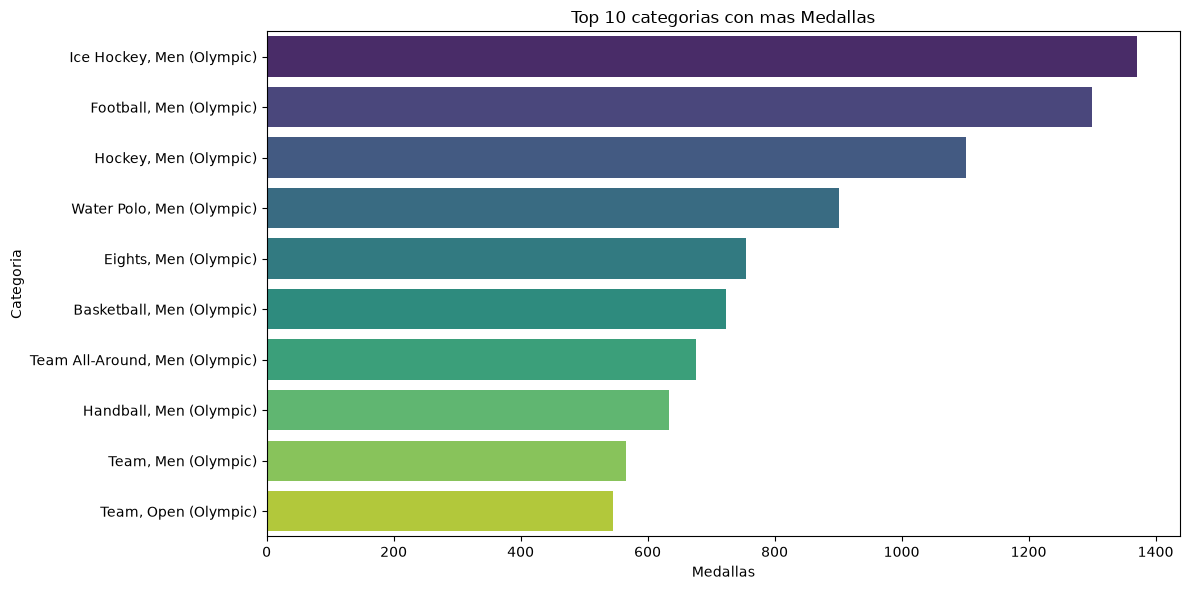

In [43]:
plt.figure(figsize=(12,6))
sns.barplot(data=top_categoria, x="Medalla",y="Categoria", palette="viridis")
plt.title("Top 10 categorias con mas Medallas")
plt.xlabel("Medallas")
plt.ylabel("Categoria")
plt.tight_layout()
plt.show()

revela qué pruebas o eventos generan más medallas dentro de la base .